# Rubí como sensor óptico de altas presiones

### Briones Andrade Joshua

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

In [2]:
plt.rcParams['figure.figsize'] = [6, 4]
plt.rcParams['figure.dpi'] = 100

In [3]:
names = ["Wavelenght (nm)", "Intensity (u.a)"]

df = []

df.append(pd.read_csv(r'./datos_rubi/01.txt',  sep="\t", header=None, names=names))
df.append(pd.read_csv(r'./datos_rubi/02.txt',  sep="\t", header=None, names=names))
df.append(pd.read_csv(r'./datos_rubi/03.txt',  sep="\t", header=None, names=names))
df.append(pd.read_csv(r'./datos_rubi/04.txt',  sep="\t", header=None, names=names))
df.append(pd.read_csv(r'./datos_rubi/05.txt',  sep="\t", header=None, names=names))
df.append(pd.read_csv(r'./datos_rubi/06.txt',  sep="\t", header=None, names=names))
df.append(pd.read_csv(r'./datos_rubi/06b.txt', sep="\t", header=None, names=names))
df.append(pd.read_csv(r'./datos_rubi/07.txt',  sep="\t", header=None, names=names))
df.append(pd.read_csv(r'./datos_rubi/08.txt',  sep="\t", header=None, names=names))
df.append(pd.read_csv(r'./datos_rubi/09.txt',  sep="\t", header=None, names=names))
df.append(pd.read_csv(r'./datos_rubi/09b.txt', sep="\t", header=None, names=names))
df.append(pd.read_csv(r'./datos_rubi/10.txt',  sep="\t", header=None, names=names))

In [4]:
longitudes = []; intensidad = []; label = [];

for i in range(12):
    longitudes.append(df[i].iloc[:,0].to_numpy())
    intensidad.append(df[i].iloc[:,1].to_numpy())
    label.append(f"datos{i+1}")

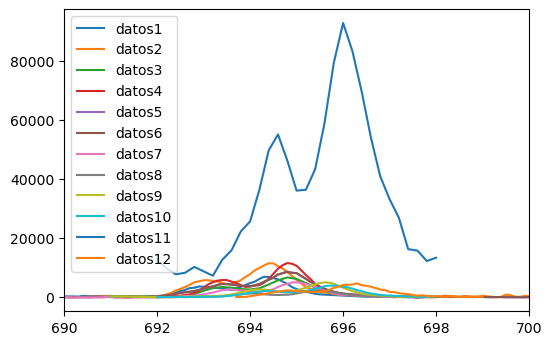

In [5]:
for i in range(12):
    plt.plot(longitudes[i], intensidad[i], label =label[i])
plt.xlim([690, 700])
plt.legend(); plt.show()

A pesar de que cada set de datos tiene un comportamiento diferente y lo podemos atribuir a errores de medición o a la precisión del instrumento, sin embargo, son lo suficientemente parecidos para poder obtener el perfil lorentziano característico de cada curva. Respecto a los datos, se muestran picos de intensidad en las regiones entre los 692 nm hasta los 698 nm aproximadamnete.

Se continua con la normalización de los datos para un mejor cálculo de los parámetros para los perfiles lorentizianos.

In [6]:
for i in range(12):
    a = np.sum(intensidad[i])
    intensidad[i] = intensidad[i]/a

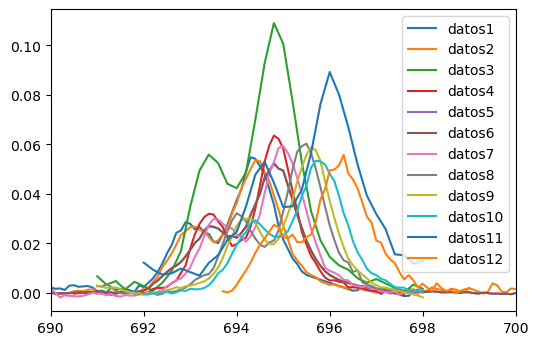

In [7]:
for i in range(12):
    plt.plot(longitudes[i], intensidad[i], label =label[i])
plt.xlim([690, 700])
plt.legend(); plt.show()

Una vez normalizadas las curvas, se continua con definir la función Lorentziana

### Distribución de Cauchy - función Lorentziana

\begin{align}
    f(x;x_0,\gamma) &=\frac{1}{\pi\gamma\left[1+\left(\frac{x-x_0}{\gamma}\right)^2\right]}\\
    &=\frac{1}{\pi}\left[\frac{\gamma}{(x-x_0)^2+\gamma^2}\right]
\end{align}


In [8]:
def lorentziana(x, x_0, gamma):
    return (1/np.pi)*(gamma/((x-x_0)**2+gamma**2))

In [9]:
from deap import tools
from deap import algorithms

def eaSimpleWithElitism(population, toolbox, cxpb, mutpb, ngen, stats=None,
             halloffame=None, verbose=__debug__):
    """This algorithm is similar to DEAP eaSimple() algorithm, with the modification that
    halloffame is used to implement an elitism mechanism. The individuals contained in the
    halloffame are directly injected into the next generation and are not subject to the
    genetic operators of selection, crossover and mutation.
    """
    logbook = tools.Logbook()
    logbook.header = ['gen', 'nevals'] + (stats.fields if stats else [])

    # Evaluate the individuals with an invalid fitness
    invalid_ind = [ind for ind in population if not ind.fitness.valid]
    fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit

    if halloffame is None:
        raise ValueError("halloffame parameter must not be empty!")

    halloffame.update(population)
    hof_size = len(halloffame.items) if halloffame.items else 0

    record = stats.compile(population) if stats else {}
    logbook.record(gen=0, nevals=len(invalid_ind), **record)
    if verbose:
        print(logbook.stream)

    # Begin the generational process
    for gen in range(1, ngen + 1):

        # Select the next generation individuals
        offspring = toolbox.select(population, len(population) - hof_size)

        # Vary the pool of individuals
        offspring = algorithms.varAnd(offspring, toolbox, cxpb, mutpb)

        # Evaluate the individuals with an invalid fitness
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        # add the best back to population:
        offspring.extend(halloffame.items)

        # Update the hall of fame with the generated individuals
        halloffame.update(offspring)

        # Replace the current population by the offspring
        population[:] = offspring

        # Append the current generation statistics to the logbook
        record = stats.compile(population) if stats else {}
        logbook.record(gen=gen, nevals=len(invalid_ind), **record)
        if verbose:
            print(logbook.stream)

    return population, logbook

gen	nevals	min       	avg     
0  	20000 	0.00191847	0.032801
1  	18437 	0.00191623	0.0325416
2  	18428 	0.00191623	0.0324212
3  	18397 	0.0018867 	0.0321334
4  	18385 	0.00173844	0.0319354
5  	18379 	0.0017338 	0.0311504
6  	18398 	0.0017338 	0.0303523
7  	18433 	0.00172103	0.0290312
8  	18445 	0.00171476	0.0277762
9  	18394 	0.00134852	0.0262363
10 	18400 	0.00134852	0.024628 
11 	18468 	0.00134852	0.0224635
12 	18383 	0.00134852	0.0207767
13 	18459 	0.00134852	0.0192965
14 	18386 	0.00134852	0.0178098
15 	18418 	0.00132326	0.0166853
16 	18410 	0.00132326	0.0155132
17 	18415 	0.00132326	0.0148248
18 	18318 	0.00116288	0.0132872
19 	18451 	0.00116288	0.0118897
20 	18474 	0.00106585	0.0102063
21 	18404 	0.00106585	0.00853187
22 	18420 	0.000884237	0.00703899
23 	18475 	0.000863183	0.00600955
24 	18411 	0.000863183	0.00546704
25 	18383 	0.000863183	0.00518023
26 	18447 	0.000863183	0.00512261
27 	18391 	0.000863183	0.00500836
28 	18414 	0.000863183	0.004984  
29 	18344 	0.000820301	0.00

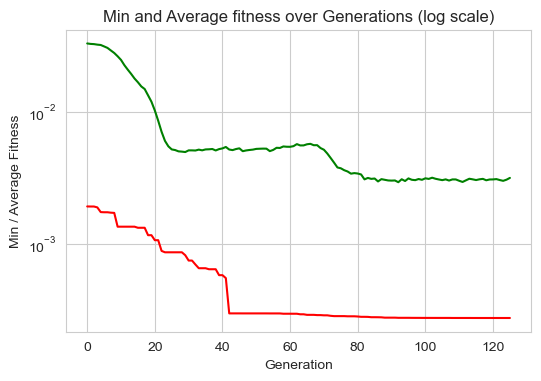

Tiempo transcurrido: 15.390406533082325 minutos


In [10]:
from deap import base, creator, tools

import random
import seaborn as sns
# import elitism

# problem constants:
DIMENSIONS = 6  # number of dimensions
BOUND_LOW, BOUND_UP = 100, 1300  # boundaries for all dimensions

# Genetic Algorithm constants:
POPULATION_SIZE = 20000
P_CROSSOVER = 0.85  # probability for crossover
P_MUTATION = 0.5   # (try also 0.5) probability for mutating an individual
MAX_GENERATIONS = 125
HALL_OF_FAME_SIZE = 100
CROWDING_FACTOR = 25.0  # crowding factor for crossover and mutation

# set the random seed:

toolbox = base.Toolbox()

# define a single objective, minimizing fitness strategy:
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))

# create the Individual class based on list:
creator.create("Individual", list, fitness=creator.FitnessMin)


# helper function for creating random real numbers uniformly distributed within a given range [low, up]
# it assumes that the range is the same for every dimension
def randomFloat(low, up):
    return [random.uniform(l, u) for l, u in zip([low] * DIMENSIONS, [up] * DIMENSIONS)]

# create an operator that randomly returns a float in the desired range and dimension:
toolbox.register("attrFloat", randomFloat, BOUND_LOW, BOUND_UP)

# create the individual operator to fill up an Individual instance:
toolbox.register("individualCreator", tools.initIterate, creator.Individual, toolbox.attrFloat)

# create the population operator to generate a list of individuals:
toolbox.register("populationCreator", tools.initRepeat, list, toolbox.individualCreator)


# Eggholder function as the given individual's fitness:
def costo(individual):
    i = 11;
    X1 = individual[0]; G1 = individual[1]; A1 = individual[2]
    X2 = individual[3]; G2 = individual[4]; A2 = individual[5]
    f = np.sum((A1/5000*lorentziana(longitudes[i], X1, G1/1000) + A2/5000*lorentziana(longitudes[i], X2, G2/1000) - intensidad[i])**2)
    return f,  # return a tuple

toolbox.register("evaluate", costo)

# genetic operators:
toolbox.register("select", tools.selTournament, tournsize=2)
toolbox.register("mate", tools.cxSimulatedBinaryBounded, low=BOUND_LOW, up=BOUND_UP, eta=CROWDING_FACTOR)
toolbox.register("mutate", tools.mutPolynomialBounded, low=BOUND_LOW, up=BOUND_UP, eta=CROWDING_FACTOR, indpb=1.0/DIMENSIONS)


# Genetic Algorithm flow:
def main():

    # create initial population (generation 0):
    population = toolbox.populationCreator(n=POPULATION_SIZE)

    # prepare the statistics object:
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("min", np.min)
    stats.register("avg", np.mean)

    # define the hall-of-fame object:
    hof = tools.HallOfFame(HALL_OF_FAME_SIZE)

    # perform the Genetic Algorithm flow with elitism:
    population, logbook = eaSimpleWithElitism(population, toolbox, cxpb=P_CROSSOVER, mutpb=P_MUTATION,
                                              ngen=MAX_GENERATIONS, stats=stats, halloffame=hof, verbose=True)

    # print info for best solution found:
    best = hof.items[0]
    print("-- Best Individual = ", best)
    print("-- Best Fitness = ", best.fitness.values[0])

    # extract statistics:
    minFitnessValues, meanFitnessValues = logbook.select("min", "avg")

    # plot statistics:
    sns.set_style("whitegrid")
    plt.plot(minFitnessValues, color='red')
    plt.plot(meanFitnessValues, color='green')
    plt.xlabel('Generation')
    plt.ylabel('Min / Average Fitness')
    plt.title('Min and Average fitness over Generations (log scale)')
    plt.yscale("log")
    plt.show()

if __name__ == "__main__":
    t = time.time()
    main()
    print("Tiempo transcurrido:", (time.time()-t)/60, "minutos")

### Ajustes de los parámetros a través de AG

In [10]:
Coef = [];

# Parámetros obtenidos para las curvas con AG.
Coef.append([692.9502646240348, 390.61475686366210/1000, 148.31442809262760/5000,
             694.3848854157076, 481.74090798679174/1000, 412.97927565411135/5000]) # curva 1 - 0.0002
Coef.append([693.0043906826933, 370.04812690382620/1000, 128.51740685772333/5000,
             694.4237477350492, 511.72313812672417/1000, 431.76904145369286/5000]) # curva 2 - 0.0002
Coef.append([693.3943368906814, 366.99973361737430/1000, 274.96151658855350/5000,
             694.8405255226832, 497.09296234610130/1000, 853.25471534291700/5000]) # curva 3 - 0.0003
Coef.append([693.3983702294880, 329.33410543580806/1000, 152.40278676007568/5000,
             694.8427864321011, 416.79716318686525/1000, 424.43219103715460/5000]) # curva 4 - 0.0002
Coef.append([693.4180387862670, 490.26837560688085/1000, 163.27063341135766/5000,
             694.8341497287067, 510.34796379102704/1000, 413.26119578927864/5000]) # curva 5 - 0.0002
Coef.append([693.3803234831499, 468.43538444168480/1000, 153.32193409425380/5000,
             694.8377247952476, 512.31772679634140/1000, 417.16304957499360/5000]) # curva 6 - 0.0002
Coef.append([693.6064028251430, 372.21830945494880/1000, 146.95914410734700/5000,
             695.0274992606043, 465.94666480260776/1000, 442.69781174936486/5000]) # curva 7 - 0.0004
Coef.append([694.0155895780692, 319.86632451819446/1000, 141.24842288340704/5000,
             695.4648099672456, 442.78758662845286/1000, 428.69686468904580/5000]) # curva 8 - 0.0002
Coef.append([694.1733557124172, 396.45301348162855/1000, 170.35893881393065/5000,
             695.6277247678097, 429.87788205233005/1000, 404.90571575431060/5000]) # curva 9 - 0.0002
Coef.append([694.3252244310837, 383.93737023797880/1000, 139.86375721432130/5000,
             695.7932254168943, 525.12072689710760/1000, 448.90648017353690/5000]) # curva 10 - 0.0002
Coef.append([694.4776419946656, 444.09075776683470/1000, 278.36856964043085/5000,
             696.0909889892362, 640.29117676058120/1000, 838.50942401771890/5000]) # curva 11 - 0.0003
Coef.append([694.7769014079025, 359.03248070040917/1000, 114.76890115153384/5000,
             696.2666595949270, 573.58954362956230/1000, 483.70713476348584/5000]) # curva 12 - 0.0002

In [11]:
np.array(Coef)[:,3]

array([694.38488542, 694.42374774, 694.84052552, 694.84278643,
       694.83414973, 694.8377248 , 695.02749926, 695.46480997,
       695.62772477, 695.79322542, 696.09098899, 696.26665959])

In [12]:
# 4e-3 = 0.004

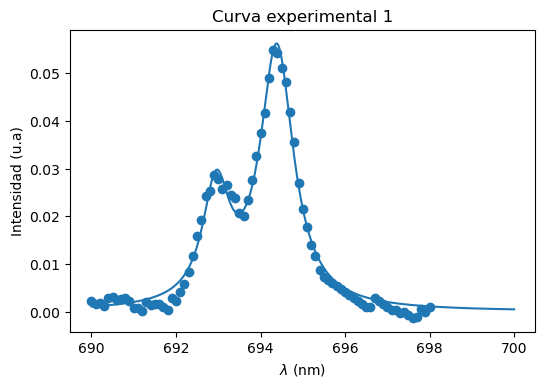

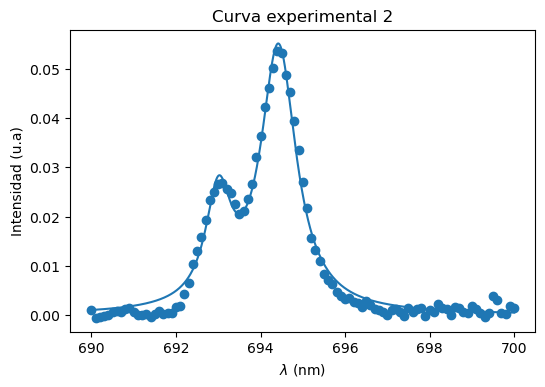

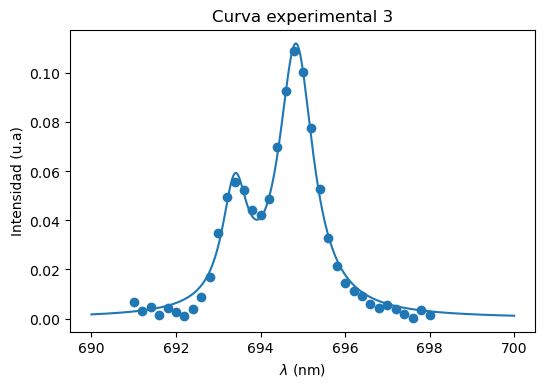

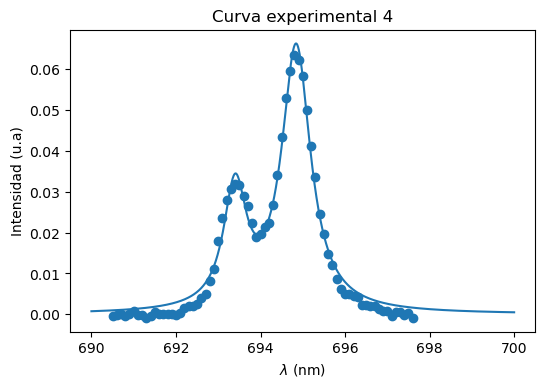

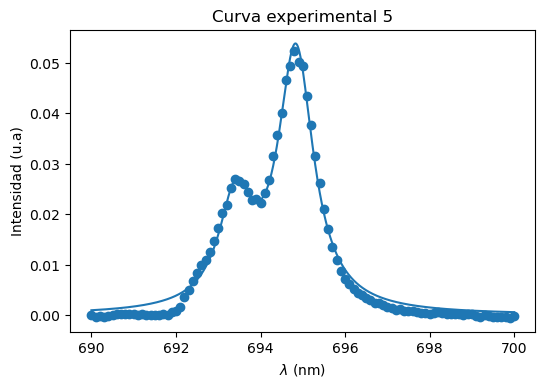

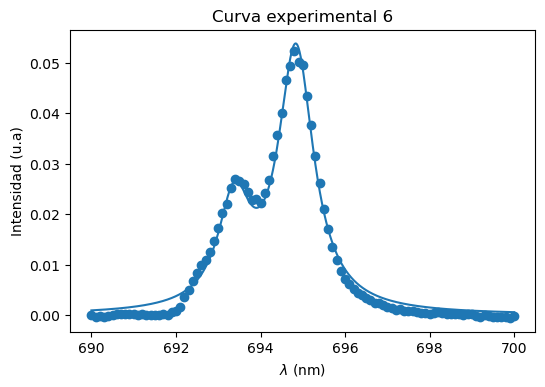

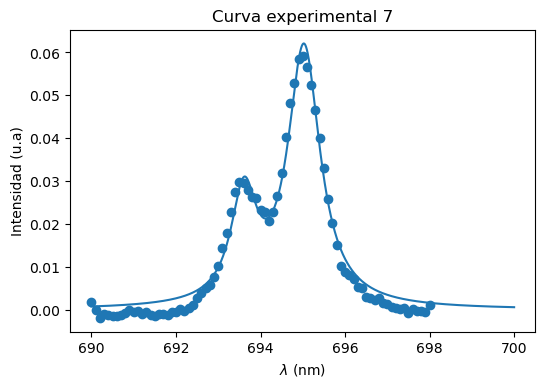

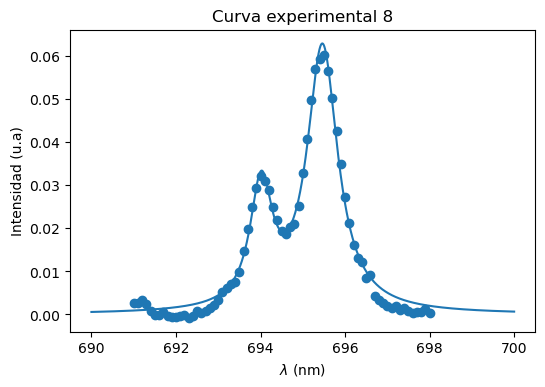

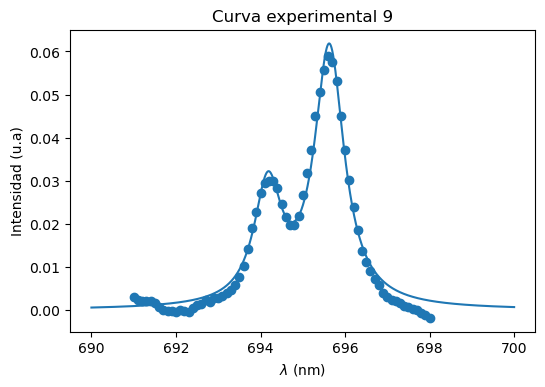

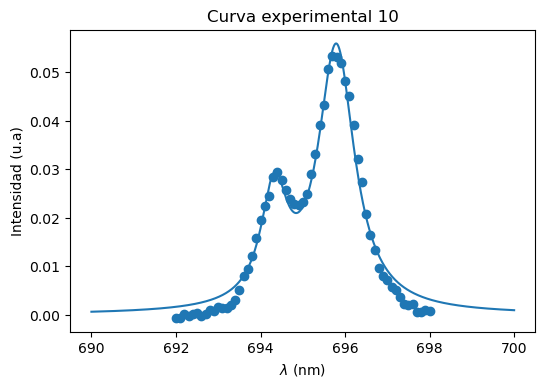

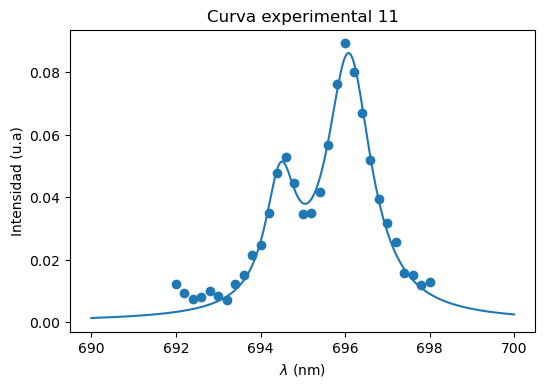

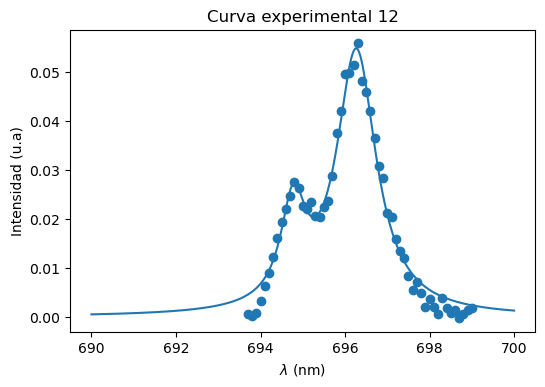

In [13]:
X = np.linspace(690,700,10000)

# plt.figure(figsize=(10,6)); plt.grid()

labels = []
for k in range(12):
    labels.append("Curva experimental "+str(k+1))
    # plt.scatter(pdist[k],voltaje[k], label=labels[k])
    plt.title(labels[k])
    plt.scatter(longitudes[k], intensidad[k])
    plt.plot(X, Coef[k][2]*lorentziana(X, Coef[k][0], Coef[k][1]) + Coef[k][5]*lorentziana(X, Coef[k][3], Coef[k][4]));
    plt.xlabel(r"$\lambda$ (nm)")
    plt.ylabel(r"Intensidad (u.a)")
#     plt.ylim(bottom=0, top=4000)
    # plt.legend(); 
    plt.show()

### Cálculo de las presiones

En la teoría encontramos por lo menos 3 ecuaciones con las que poder calcular las presiones a las que están sometidos los rubíes.



\begin{equation}\label{eq:jayaraman}
    P(\text{GPa})=380.8\left[\left(\frac{\Delta\lambda}{694.2}+1 \right)^5-1\right]
\end{equation}

\begin{equation}\label{eq:rodriguez}
    P(\text{GPa})=1884\left(\frac{\lambda}{\lambda_0}-1\right) \left[1+5.5\left(\frac{\lambda}{\lambda_0}-1\right)\right]
\end{equation}

\begin{equation}\label{eq:michael}
    P(\text{GPa})=\frac{1904}{B}\left[\left(1+ \frac{\Delta\lambda}{694.24} \right)^B-1\right],
\end{equation}


In [14]:
lambda_0 = 694.3 #(nm) R1 at P=0 GPa

def P3(lambda_1):
    delta = np.abs(lambda_0-lambda_1)
    return 380.8*(((delta/694.2)+1)**5-1)

def P4(lambda_1):
    return 1884*(lambda_1/lambda_0 - 1)*(1+ 5.5*(lambda_1/lambda_0 - 1))

def P5(lambda_1):
    delta = np.abs(lambda_0-lambda_1); B = 7.665
    return (1904/B)*((1+(delta/694.24))**B-1)

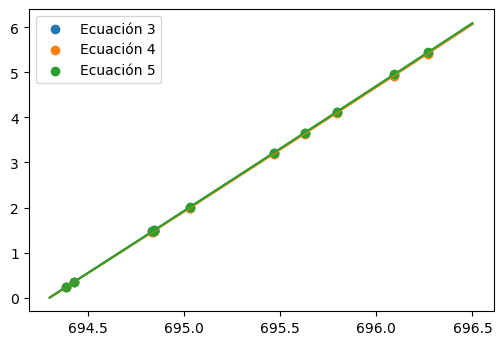

In [15]:
X = np.linspace(694.3,696.5,10000)
Presiones = [P3,P4,P5];

for i in range(3):
    plt.scatter(np.array(Coef)[:,3], Presiones[i](np.array(Coef)[:,3]), label=f"Ecuación {i+3}")
    plt.plot(X, Presiones[i](X))
    plt.legend()
#     plt.title(f"Ecuación {i+3}"); 
#     plt.show()
plt.show()

Por lo anterior podemos asegurar que las 3 ecuaciones son casi idénticas en el rango de presiones explorado.
Ahora podemos calcular el coeficiente $d\lambda/dP$ a partir de la ecuación \ref{eq:jayaraman}.

In [16]:
380.8*(5/694.2), 1/(380.8*(5/694.2))

(2.7427254393546527, 0.3646008403361345)

\begin{equation}\label{eq:}
    \frac{d\lambda}{dP}=\frac{694.2}{5(380.8)}\left(\frac{\Delta\lambda}{694.2}+1 \right)^{-4}
\end{equation}


In [17]:
def dlambda(lambda_1):
    delta = np.abs(lambda_0-lambda_1)
    return 694.2/(5*380.8)*((delta/694.2)+1)**(-4)

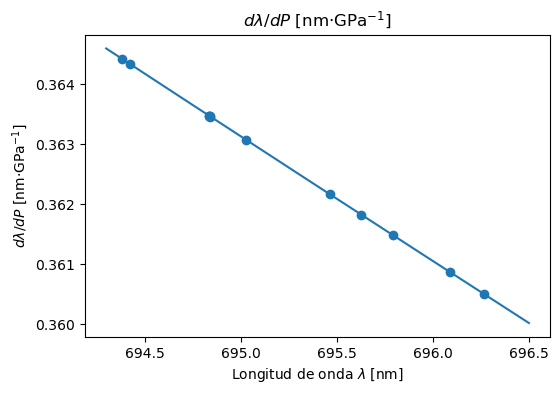

In [18]:
X = np.linspace(694.3,696.5,10000)
Presiones = [P3,P4,P5];

plt.scatter(np.array(Coef)[:,3], dlambda(np.array(Coef)[:,3]))
plt.plot(X, dlambda(X))
plt.xlabel(r"Longitud de onda $\lambda$ [nm]")
plt.ylabel(r"$d\lambda/dP$ [nm$\cdot$GPa$^{-1}$]")
plt.title(r"$d\lambda/dP$ [nm$\cdot$GPa$^{-1}$]")
#     plt.title(f"Ecuación {i+3}"); 
#     plt.show()
plt.show()

In [18]:
a = (np.mean(dlambda(np.array(Coef)[:,3])), np.std(dlambda(np.array(Coef)[:,3])))
f"Tasa de corrimiento: {a[0], a[1]}"

'Tasa de corrimiento: (0.3627128786666172, 0.0012564124992390274)'

$\frac{d\lambda}{dP} = 0.3671 \pm 0.0013$

In [19]:
b = 0.364;
np.abs((a[0]-b)/b)*100

0.35360476191834284

In [22]:
2-1

1

In [24]:
(93.79-89)/93.79*100

5.107154280840182